# Plot Beginning Supply Network
This notebook loads beginning.gpkg, plots Nigeria as background, shows facility points, and draws straight links from each facility to its nearest primary storage using tank_name.

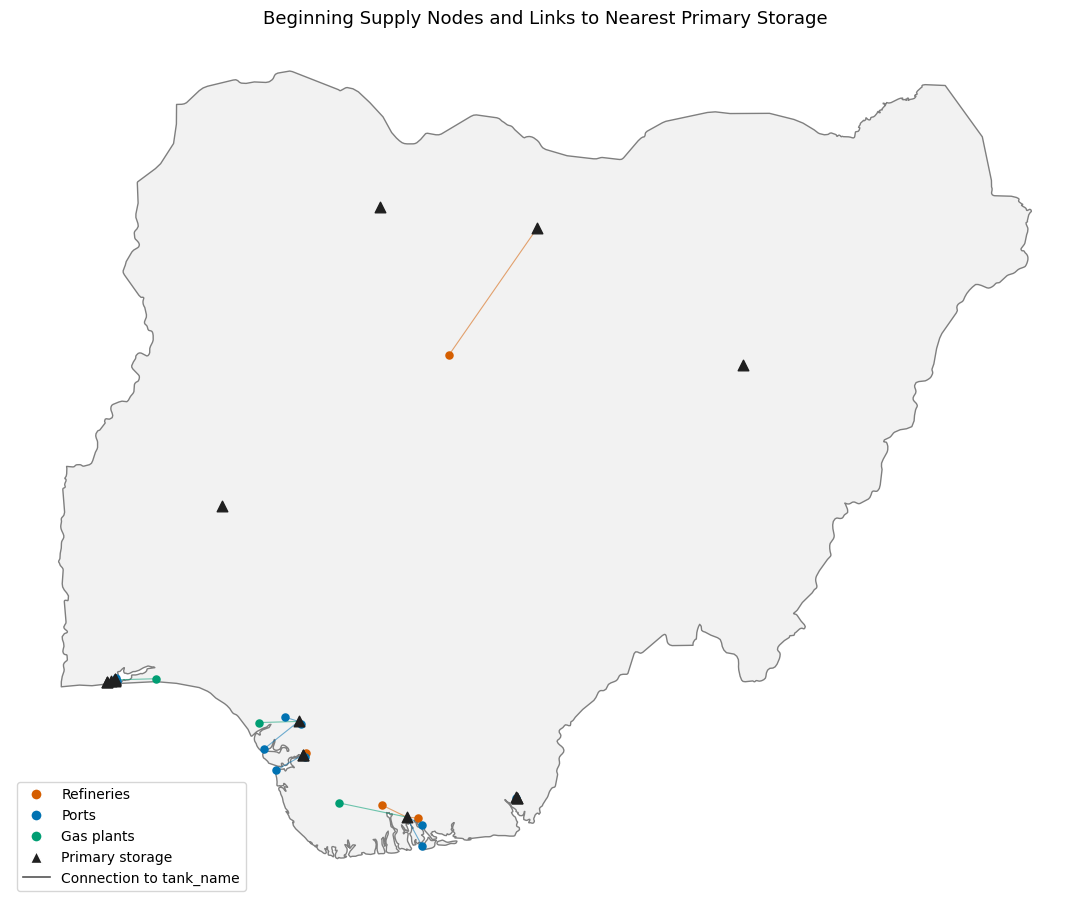

Map saved to: thesis\script_nostri\dataset_first_step\beginning_map_connections.png
refineries: unmatched tank_name rows = 0
ports: unmatched tank_name rows = 0
gas_plants: unmatched tank_name rows = 0


In [1]:
from pathlib import Path
import urllib.request
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import LineString

# ---- Input / output paths ----
candidate_inputs = [
    Path("dataset_first_step") / "beginning.gpkg",
    Path("thesis") / "script_nostri" / "dataset_first_step" / "beginning.gpkg",
]
gpkg_path = next((p for p in candidate_inputs if p.exists()), None)
if gpkg_path is None:
    raise FileNotFoundError(
        "Could not find beginning.gpkg. Checked: " + ", ".join(str(p) for p in candidate_inputs)
    )

output_png = gpkg_path.with_name("beginning_map_connections.png")
cache_dir = Path.home() / ".geopandas_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

# ---- Load Nigeria boundary from Natural Earth ----
world_shp = cache_dir / "ne_10m_admin_0_countries.shp"
if not world_shp.exists():
    ne_zip = cache_dir / "ne_10m_admin_0_countries.zip"
    ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
    print("Downloading Natural Earth country boundaries...")
    urllib.request.urlretrieve(ne_url, ne_zip)
    with zipfile.ZipFile(ne_zip, "r") as zf:
        zf.extractall(cache_dir)

world = gpd.read_file(world_shp)
name_col = "NAME" if "NAME" in world.columns else "name"
if name_col not in world.columns:
    for col in world.columns:
        if str(col).lower() == "name":
            name_col = col
            break

nigeria = world[world[name_col].astype(str).str.lower() == "nigeria"].copy()
if nigeria.empty:
    raise ValueError("Nigeria boundary not found in Natural Earth dataset")
nigeria = nigeria[["geometry"]].to_crs("EPSG:4326").dissolve().reset_index(drop=True)

# ---- Load required layers from beginning.gpkg ----
required_layers = ["refineries", "ports", "gas_plants", "primary_storage"]
layers = {name: gpd.read_file(gpkg_path, layer=name) for name in required_layers}

# Ensure point geometries
for key in required_layers:
    gdf = layers[key].copy()
    non_points = gdf.geometry.geom_type != "Point"
    if non_points.any():
        gdf.loc[non_points, "geometry"] = gdf.loc[non_points, "geometry"].centroid
    layers[key] = gdf.to_crs("EPSG:4326")

# Find name field in primary_storage
storage = layers["primary_storage"]
storage_name_col = "name" if "name" in storage.columns else None
if storage_name_col is None:
    for col in storage.columns:
        if str(col).lower() == "name":
            storage_name_col = col
            break
if storage_name_col is None:
    raise ValueError("primary_storage layer has no name column")

storage_lookup = {}
for _, row in storage.iterrows():
    k = str(row[storage_name_col]).strip()
    if k and k.lower() not in {"nan", "none"}:
        storage_lookup[k] = row.geometry

# Build connection lines using tank_name
facility_layers = ["refineries", "ports", "gas_plants"]
connections = {}
unmatched = {}

for fac_name in facility_layers:
    fac = layers[fac_name]
    if "tank_name" not in fac.columns:
        raise ValueError(f"Layer '{fac_name}' has no 'tank_name' field")

    lines = []
    miss = 0
    for _, row in fac.iterrows():
        tn = str(row["tank_name"]).strip()
        if not tn or tn.lower() in {"nan", "none"}:
            miss += 1
            continue

        tank_geom = storage_lookup.get(tn)
        if tank_geom is None:
            miss += 1
            continue

        lines.append({"tank_name": tn, "geometry": LineString([row.geometry, tank_geom])})

    connections[fac_name] = gpd.GeoDataFrame(lines, geometry="geometry", crs=fac.crs)
    unmatched[fac_name] = miss

# ---- Plot ----
colors = {
    "refineries": "#d55e00",
    "ports": "#0072b2",
    "gas_plants": "#009e73",
}

fig, ax = plt.subplots(figsize=(11, 11))
nigeria.plot(ax=ax, color="#f2f2f2", edgecolor="#7f7f7f", linewidth=1.0, zorder=1)

for fac_name in facility_layers:
    conn = connections[fac_name]
    if not conn.empty:
        conn.plot(ax=ax, color=colors[fac_name], linewidth=0.8, alpha=0.55, zorder=2)

for fac_name in facility_layers:
    layers[fac_name].plot(ax=ax, color=colors[fac_name], markersize=26, marker="o", zorder=3)

storage.plot(ax=ax, color="#202020", markersize=58, marker="^", zorder=4)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="Refineries", markerfacecolor=colors["refineries"], markersize=8),
    Line2D([0], [0], marker="o", color="w", label="Ports", markerfacecolor=colors["ports"], markersize=8),
    Line2D([0], [0], marker="o", color="w", label="Gas plants", markerfacecolor=colors["gas_plants"], markersize=8),
    Line2D([0], [0], marker="^", color="w", label="Primary storage", markerfacecolor="#202020", markersize=9),
    Line2D([0], [0], color="#555555", lw=1.2, label="Connection to tank_name"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=True)
ax.set_title("Beginning Supply Nodes and Links to Nearest Primary Storage", fontsize=13)
ax.set_axis_off()
fig.tight_layout()

output_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Map saved to: {output_png}")
for fac_name in facility_layers:
    print(f"{fac_name}: unmatched tank_name rows = {unmatched[fac_name]}")